## Prediction Insight Engine

**Import Libraries**

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
import time

**Load Dataset**

In [47]:
df = pd.read_csv("RealEstate_HousePrice_Dataset.csv")

print(df.head())


   house_id  area_sqft  ...  renovation_years_ago  house_price_inr
0    100001       1973  ...                     0         40275084
1    100002       1560  ...                    13         26812029
2    100003       2071  ...                     9         29315677
3    100004       2640  ...                     4         47712959
4    100005       1498  ...                    15         17724566

[5 rows x 12 columns]


## Part B: Dataset Understanding & Preparation

**Q7 

In [48]:

# Independent variables

x = df[ [
    "house_id",
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "location_score",
    "age_years",
    "distance_city_km",
    "lot_size_sqft",
    "has_garage",
    "has_pool",
    "renovation_years_ago"
] ]

# Dependent variables

y = df["house_price_inr"]

print("Independent variables:")
print(x.columns)

print("Dependent Variable:")
print(y.name)

Independent variables:
Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage',
       'has_pool', 'renovation_years_ago'],
      dtype='str')
Dependent Variable:
house_price_inr


**Interpretation:**

The independent variables are the features used to predict house price, such as area, number of bedrooms, number of bathrooms, location score, and age of the property. The dependent variable is house_price_inr, which is the target variable that the model tries to predict.

**Q8 — Visualize relationships**

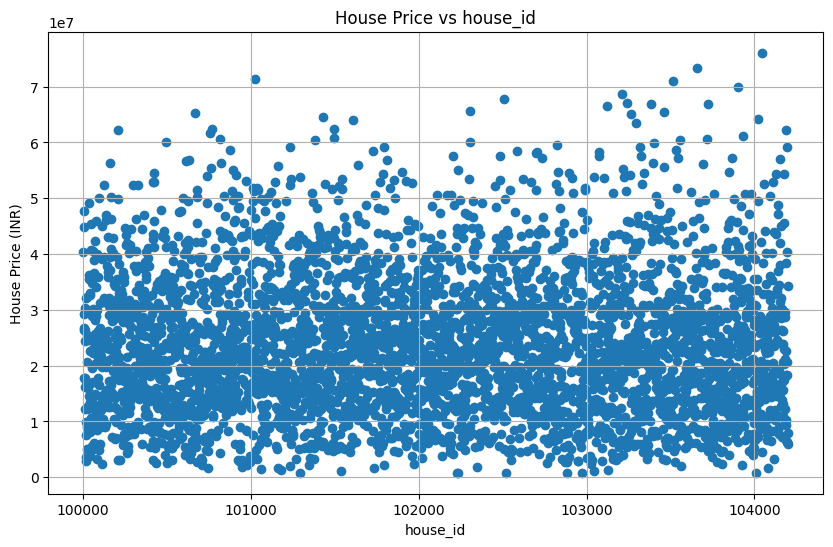

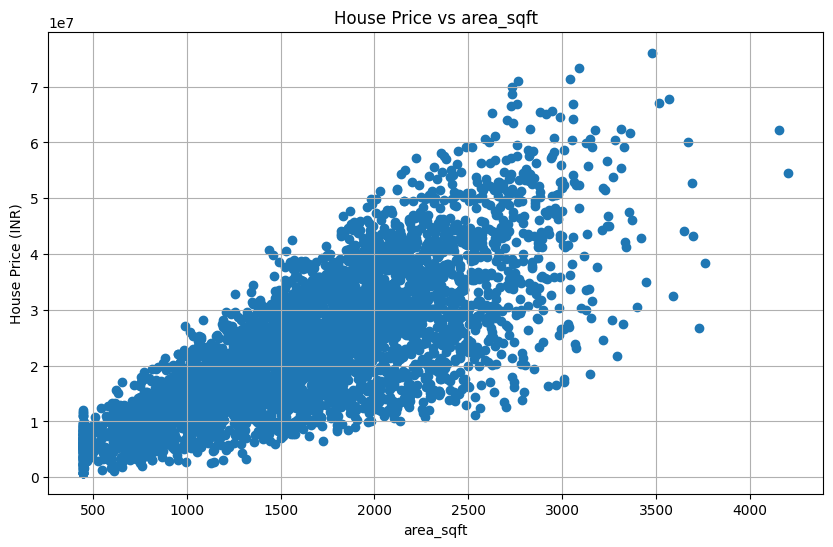

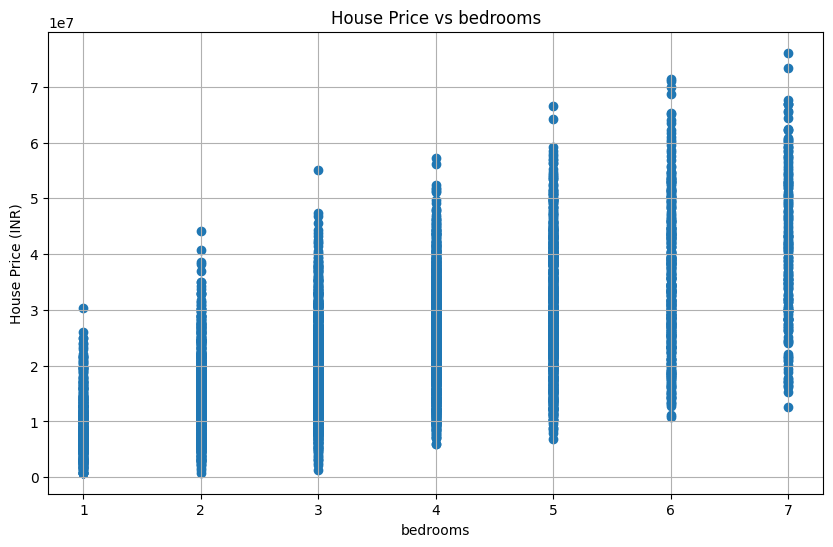

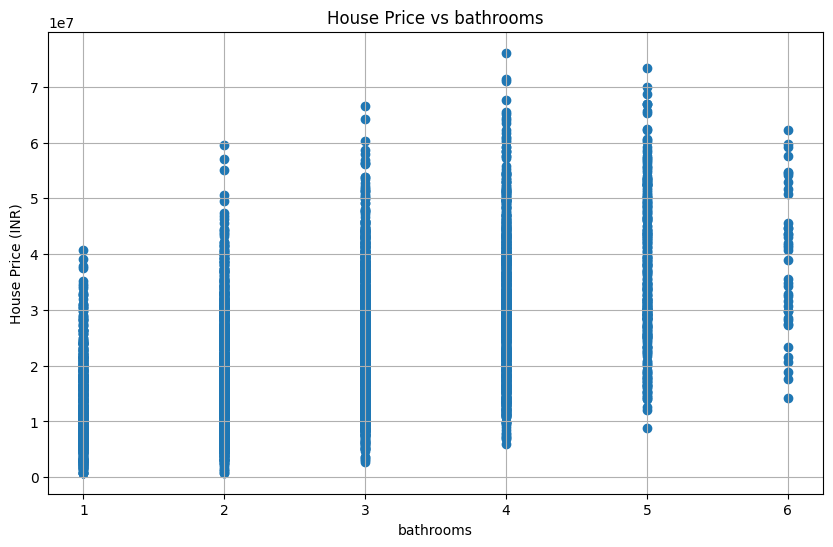

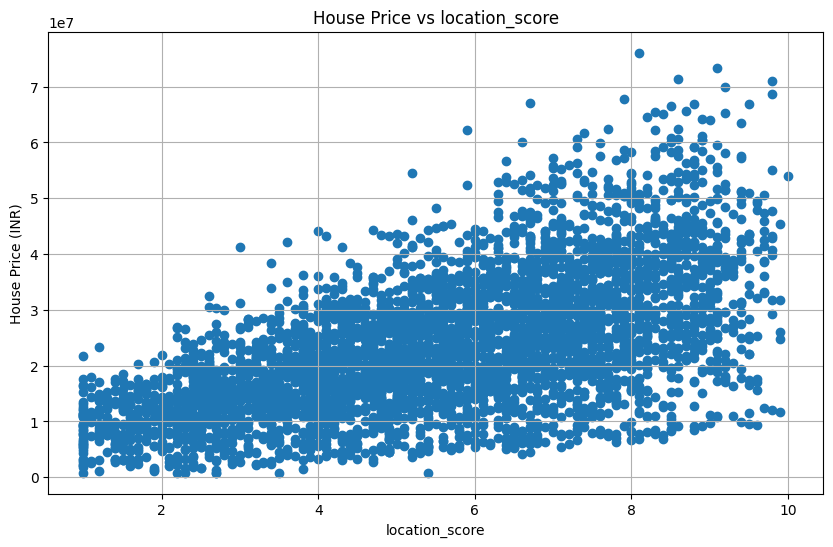

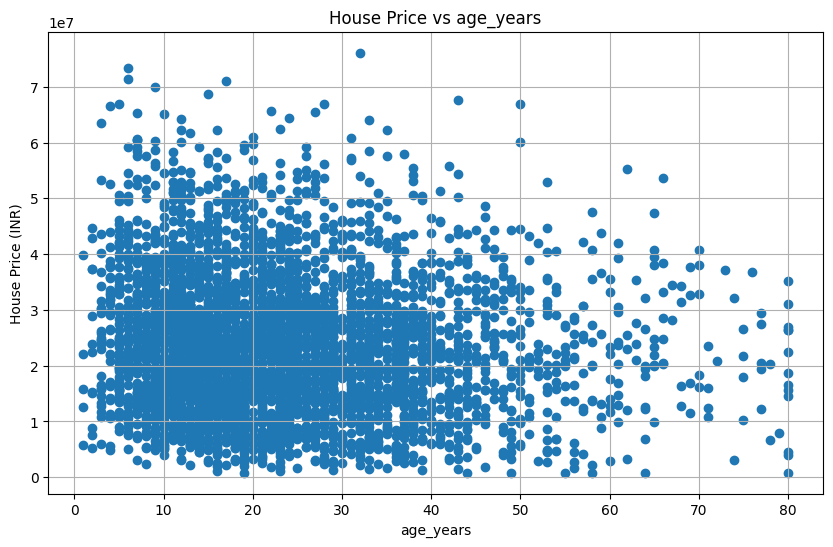

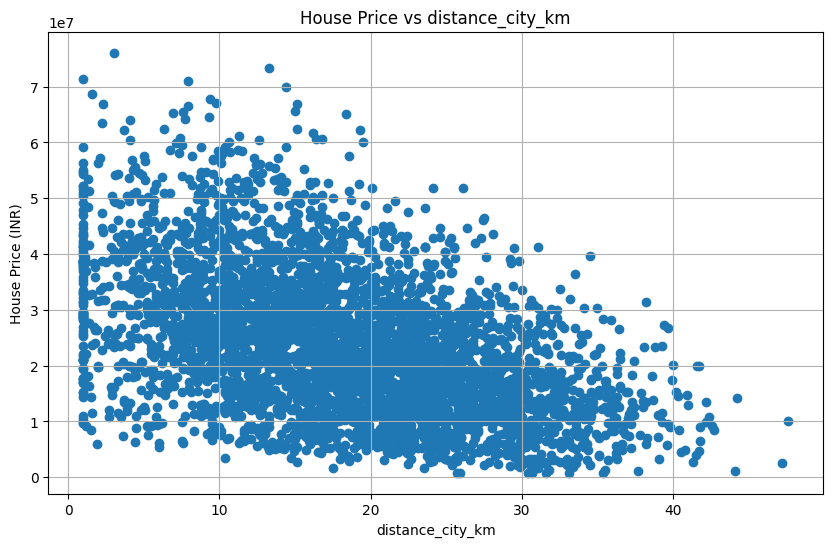

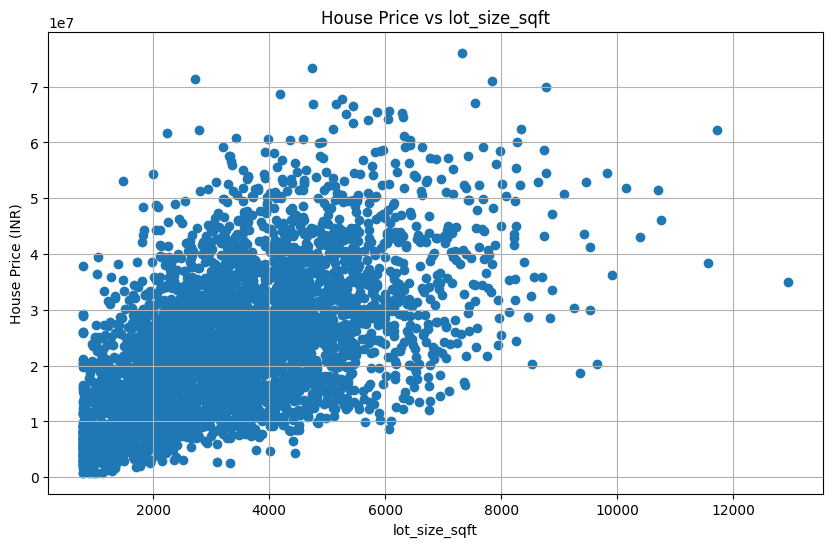

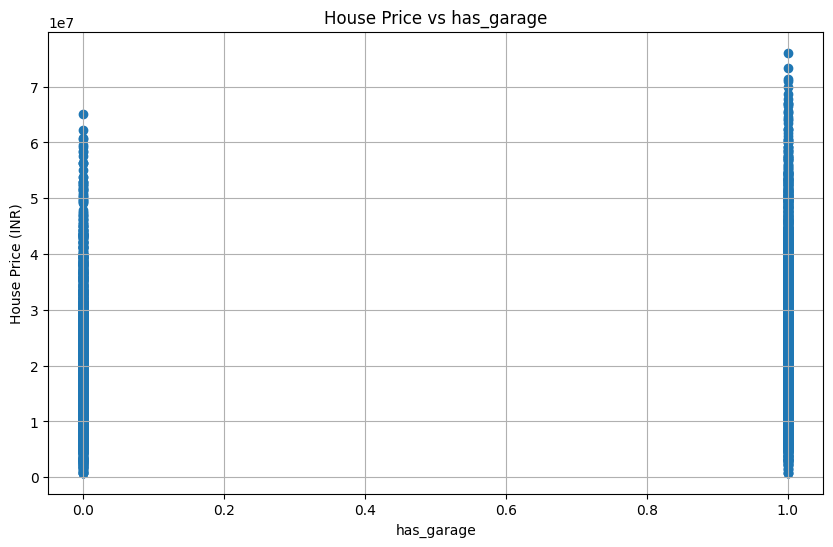

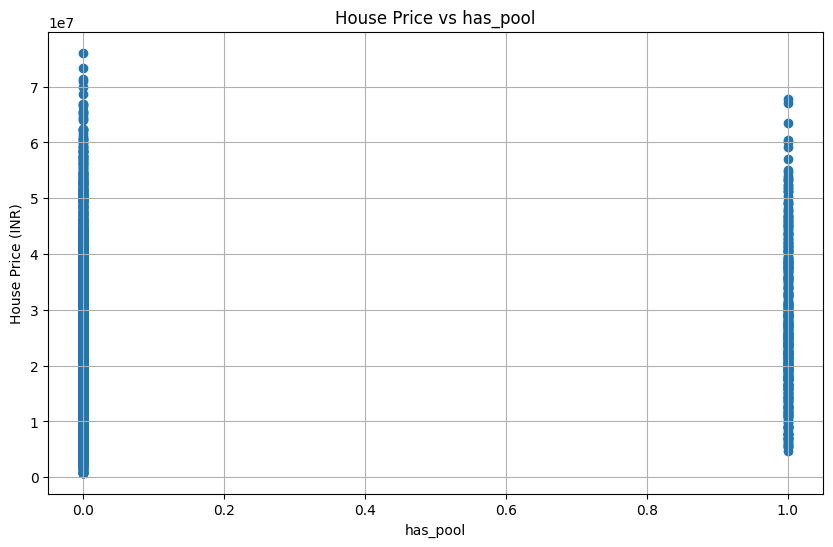

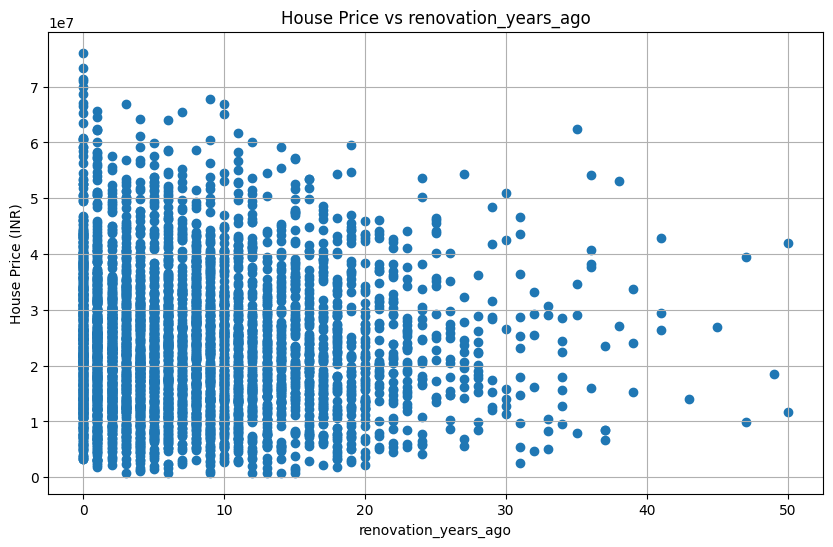

In [49]:
features = [
    "house_id",
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "location_score",
    "age_years",
    "distance_city_km",
    "lot_size_sqft",
    "has_garage",
    "has_pool",
    "renovation_years_ago"
]

for features in features:
    plt.figure(figsize=(10, 6))
    plt.scatter(df[features], df["house_price_inr"])
    plt.xlabel(features)
    plt.ylabel("House Price (INR)")
    plt.title(f"House Price vs {features}")
    plt.grid(True)
    plt.show()

**Interpretation:**

The scatter plots show the relationship between each independent feature and house price. A clear upward or downward pattern indicates that the feature may have a relationship with house price. A random pattern indicates a weaker relationship.

**Q9 — Train/Test Split**

In [50]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Training data",x_train.shape)
print("Testing data", x_test.shape)

Training data (3360, 11)
Testing data (840, 11)


**Interpretation:**

The dataset was divided into training and testing sets. The training data is used to train the model, while the testing data is used to evaluate how well the model performs on unseen data. An 80:20 split means 80% of the data is used for training and 20% for testing.

## Part C — Simple Linear Regression

**Q10 — Using House Area**

In [51]:

x = df[["area_sqft"]]
y = df["house_price_inr"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(y_pred)

[34402357.02127602 27333546.70007102 26771591.06784133 21802720.214442
 31045411.53400921 24287155.64114167 18608446.09439958 37419171.46798276
 27244816.86340318 28043385.39341378 13402962.34321932 12663547.03765394
 27274393.47562579 15931762.68825291 17765512.64605504 24050542.74336075
 35851611.02018416 21403435.9494367  33529846.96070888 33130562.69570357
 29374332.94343146  8079172.14314861 27067357.19006748 33145351.00181488
 23961812.9066929  28841953.92342439 36428354.95852516 20752750.48053917
 26860320.90450918 25144877.39559751 31888344.98235374 18845058.99218049
 20767538.78665048 35792457.79573893 32701701.81847566 22246369.39778123
 12841006.71098964 20161218.23608686 29921500.26954984 10238264.83539951
 22630865.35667522 16419776.78992606 19007730.35940488 26076540.68060988
 39593052.46634497 31193294.59512229 16893002.5854879  27777195.88341025
 44887266.05419306 24405462.09003213 30542609.12622476 32820008.26736612
 18830270.68606919 23030149.62168053 21817508.5205533

**Interpretation:**

Simple Linear Regression was used to predict house price using area_sqft as the independent variable. The model learns the relationship between house area and house price.

**Q11 — Plot regression line**

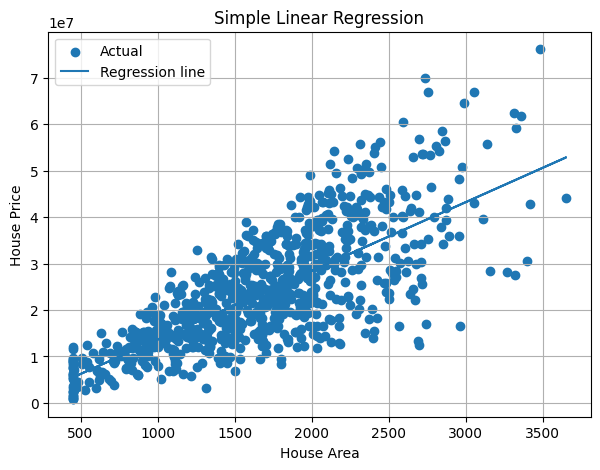

In [52]:
plt.figure(figsize=(7,5))

plt.scatter(x_test, y_test,label="Actual")
plt.plot(x_test, y_pred, label="Regression line")

plt.xlabel("House Area")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

**Interpretation:**

The regression line represents the relationship between house area and house price. The closer the actual observations are to the regression line, the better the model represents the relationship.

**Q12 — Check assumptions**

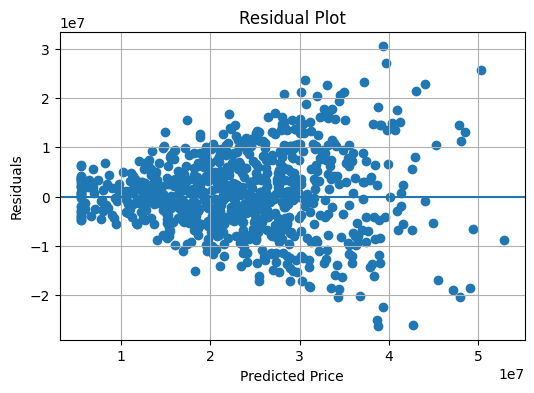

In [53]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

**Interpretation:**

The residual plot is used to check whether the errors are randomly distributed around zero. If the residuals are randomly scattered without a clear pattern, the linearity assumption is reasonably satisfied. A visible pattern may indicate that a linear model is not sufficient.

## Part D — Model Evaluation

**Q13 — MSE, MAE, RMSE, R², Adjusted R²**

In [54]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
rmse = np.sqrt(mse)

n = len(y_test)
p = x_test.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)
print("RMSE:", rmse)
print("Adjusted R2:", adjusted_r2) 

MSE: 66989260021849.47
MAE: 6294593.696131912
R2: 0.5625199587991578
RMSE: 8184696.696997969
Adjusted R2: 0.5619979062440257


**Interpretation:**

The model was evaluated using MSE, MAE, RMSE, R², and Adjusted R². Lower MSE, MAE, and RMSE indicate smaller prediction errors, while higher R² indicates that the model explains more variation in house prices.

**Q14 — Interpretation**

MSE: Measures average squared prediction error. Lower is better.

MAE: Average absolute difference between actual and predicted house prices. Lower is better and easier to interpret.

RMSE: Square root of MSE. It gives more importance to large errors. Lower is better.

R²: Shows how much variation in house price is explained by the model. Higher is generally better.

Adjusted R²: Similar to R² but accounts for the number of predictors. It is particularly useful when comparing models with different numbers of features.

## Part E — Multiple Linear Regression

**Q15 — Use all features**

In [55]:
x = df[ [
    "house_id",
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "location_score",
    "age_years",
    "distance_city_km",
    "lot_size_sqft",
    "has_garage",
    "has_pool",
    "renovation_years_ago"
] ]

y = df["house_price_inr"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(x_train, y_train)

y_pred_multi = model_multi.predict(x_test)
print(y_pred_multi)

[39047318.73935108 31354554.26440008 16530039.70939722 31612138.45466145
 21141040.04304755 29027634.71059286  8348107.39758078 41456782.23540315
 20117283.29949798 41803941.5815156  26318626.18617691 14423121.68652297
 21703986.62859432 17337502.60955603 16096232.71111846 32796477.89539239
 26718391.66394682 11001876.58981334 34429993.61462647 47676486.30005872
 24956745.84688475  2296706.15786691 29289473.68146792 44360169.44222067
 26992742.02426368 20318939.07842102 31652274.88241753 13278020.95774946
 37086614.80044855 17672112.78022144 44404881.42253776 30754786.2130959
 26146309.77470951 26085147.22420278 23912809.69523252 20820058.17566042
 21626550.97446877 16405637.82729122 37959264.31030118 16847605.12370331
 19151031.76177598 19487452.68575668 25124697.38090822 24569667.00544449
 39687803.46775001 28065224.68112809 21605164.68596664 36640244.36169606
 43034475.94773656 15610969.94271775 40453279.26119798 31317237.60969054
 24808155.09454318 24236645.59466716 28587504.322528

**Interpretation:**

Multiple Linear Regression uses several independent variables simultaneously to predict house price. Features such as area, bedrooms, bathrooms, location score, and property age provide more information than using house area alone.

**Q16 — Compare with Simple Linear Regression**

In [56]:
mse_multi = mean_squared_error(y_test, y_pred_multi)
mae_multi = mean_absolute_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)

print("Multiple Linear Regression Metrics:")
print("MSE:", mse_multi)
print("MAE:", mae_multi)
print("R2:", r2_multi)
print("RMSE:", rmse_multi)

Multiple Linear Regression Metrics:
MSE: 12597222158307.7
MAE: 2605648.611505146
R2: 0.9177325847899332
RMSE: 3549256.5641705445


**Interpretation:**

Multiple Linear Regression can provide better predictions than Simple Linear Regression when the additional features contain useful information about house prices. This can be observed through lower MAE/RMSE and higher R² on the test data.

**Q17 — Why performance may improve**

Multiple Linear Regression uses more information about the house.

For example:

House Area

Bedrooms

Bathrooms

Location Score

Age

       ↓

House Price

House price usually depends on more than just area. Therefore, adding useful features can improve prediction.

However, adding irrelevant or highly correlated features can sometimes make the model worse or less stable.

## Part F — Polynomial Regression

**Q18 — Polynomial Regression Degree 2**

In [57]:
x = df[["area_sqft"]]
y = df["house_price_inr"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

poly = PolynomialFeatures(degree=2)

x_train_poly = poly.fit_transform(x_train)
y_train_poly = poly.transform(x_test)

poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train)

y_pred_poly = poly_model.predict(y_train_poly)

**Interpretation:**

Polynomial Regression was implemented with degree 2 to capture a possible non-linear relationship between house area and house price. Unlike a straight line, the polynomial model can represent a curved relationship.

**Q19. Compare Linear vs Polynomial Regression**

In [58]:
linear_model = LinearRegression()

linear_model.fit(x_train, y_train)

y_pred_linear = linear_model.predict(x_test)

# Calculate metrics

# Linear Regression

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test,y_pred_linear)

# Polynomial Regression

poly_mae = mean_absolute_error(y_test, y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
poly_r2 = r2_score(y_test, y_pred_poly)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2:", linear_r2)

print("\nPolynomial Regression")
print("MAE:", poly_mae)
print("RMSE:", poly_rmse)
print("R2:", poly_r2)

Linear Regression
MAE: 6294593.696131912
RMSE: 8184696.696997969
R2: 0.5625199587991578

Polynomial Regression
MAE: 6292394.5612817025
RMSE: 8183089.094113434
R2: 0.5626917978136475


**📊 Visual comparison**

**Linear**

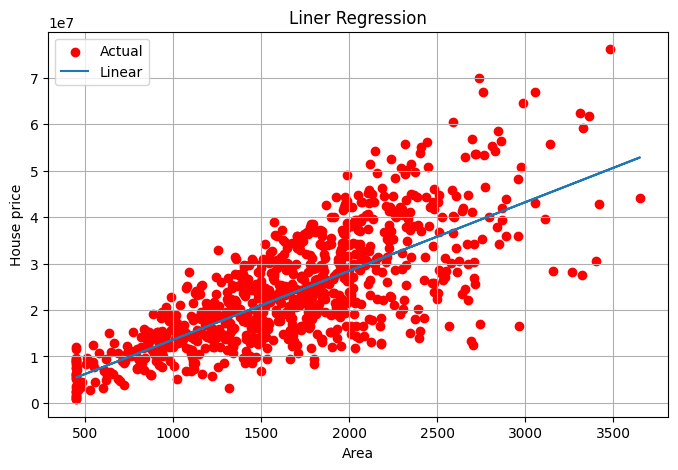

In [59]:
plt.figure(figsize=(8,5))

plt.scatter(x_test, y_test, label = "Actual", color ="red")
plt.plot(x_test, y_pred_linear, label = "Linear")

plt.xlabel("Area")
plt.ylabel("House price")
plt.title("Liner Regression")
plt.grid(True)
plt.legend()
plt.show()

**Polynomial**

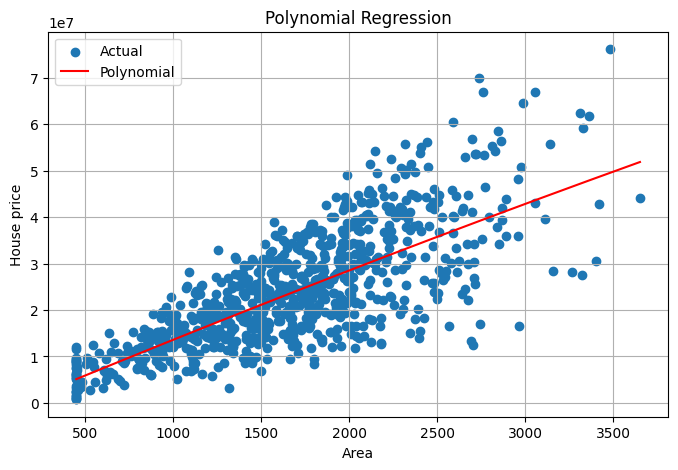

In [60]:
plot_data = x_test.copy()

plot_data["prediction"] = y_pred_poly

plot_data = plot_data.sort_values("area_sqft")

plt.figure(figsize=(8,5))
plt.scatter(x_test, y_test, label = "Actual")
plt.plot(plot_data["area_sqft"],plot_data['prediction'],label ="Polynomial",color = "red")
plt.xlabel("Area")
plt.ylabel("House price")
plt.title("Polynomial Regression")
plt.grid(True)
plt.legend()
plt.show()

**Interpretation:**

The Linear Regression model produces a straight-line relationship, while Polynomial Regression can capture curvature in the data. The models are compared using MAE, RMSE, and R². The model with lower MAE/RMSE and higher test R² provides better predictive performance.

**Q20: Identify signs of overfitting or underfitting**

In [61]:
linear_train_r2 = r2_score(y_train, linear_model.predict(x_train))
linear_test_r2 = r2_score(y_test, y_pred_linear)

poly_train_r2 = r2_score(y_train, poly_model.predict(x_train_poly))
poly_test_r2 = r2_score(y_test, y_pred_poly)

print("Polynomial Training R2:", poly_train_r2)
print("Polynomial Testing R2:", poly_test_r2)

Polynomial Training R2: 0.5724674245504779
Polynomial Testing R2: 0.5626917978136475


**Interpretation:**

Training and testing R² values are compared to identify overfitting or underfitting.

If Train R² is high and Test R² is much lower:

The model shows signs of overfitting because it performs very well on training data but poorly on unseen testing data.

If both are low:

The model shows signs of underfitting because it is unable to capture the relationship in both training and testing data.

If both are high and close:

The model provides a good fit and generalizes well to unseen data.

## Part G: Gradient Descent Optimization 

**Q21. Explain Gradient Descent**

Gradient Descent ek optimization algorithm hai jo model ke parameters ko gradually update karta hai taaki error/cost minimum ho.

Start with random/initial values
          ↓

Make prediction

          ↓

Calculate error

          ↓

Calculate gradient


          ↓

Update parameters

          ↓

Repeat

          ↓

Minimum error

Easy example

Agar model ka error bahut high hai, Gradient Descent parameters ko thoda-thoda change karta hai aur error kam karta hai.

**Interpretation:**

Gradient Descent is an optimization algorithm used to minimize the cost function. It repeatedly updates the model parameters in the direction that reduces the prediction error.

**Q22. Implement Batch Gradient Descent from Scratch**

Beta 0: 1.1139026209353441e-16
Beta 1: 0.7554338331792643


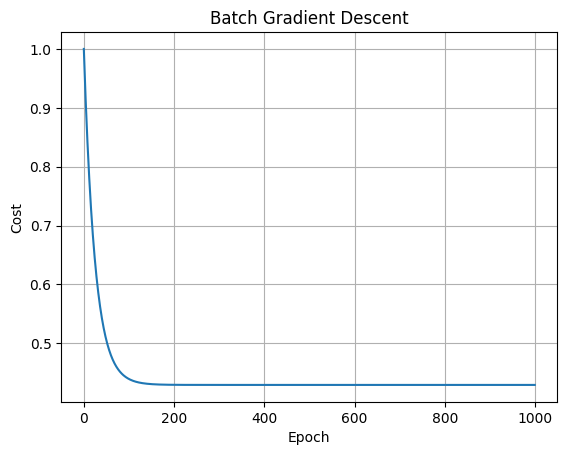

In [62]:
x = df["area_sqft"].values
y = df["house_price_inr"].values

x_mean = np.mean(x)
x_std = np.std(x)

y_mean = np.mean(y)
y_std = np.std(y)

x = (x - x_mean) / x_std
y = (y - y_mean) / y_std

beta0 = 0
beta1 = 0

learning_rate = 0.01
epochs = 1000

costs = []

n = len(x)

for epoch in range(epochs):
        y_pred = beta0 + beta1 * x
        error = y_pred - y

        cost = np.mean(error**2)
        costs.append(cost)

        grandient_b0 = (2/n) * np.sum(error)
        grandient_b1 = (2/n) * np.sum(error * x)

        beta0 = beta0 - learning_rate * grandient_b0
        beta1 = beta1 - learning_rate * grandient_b1

print("Beta 0:", beta0)
print("Beta 1:", beta1)

plt.plot(costs)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Batch Gradient Descent")
plt.grid(True)
plt.show()

**Interpretation:**

Batch Gradient Descent uses the entire training dataset to calculate the gradient before updating the parameters. Therefore, its convergence is generally stable and smooth.

If your cost graph decreases:

The decreasing cost curve indicates that the algorithm is successfully minimizing the error and converging toward a solution.

**Q23. Stochastic Gradient Descent (SGD)**

Beta 0: 0.11111375023348187
Beta 1: 0.9185440730973732


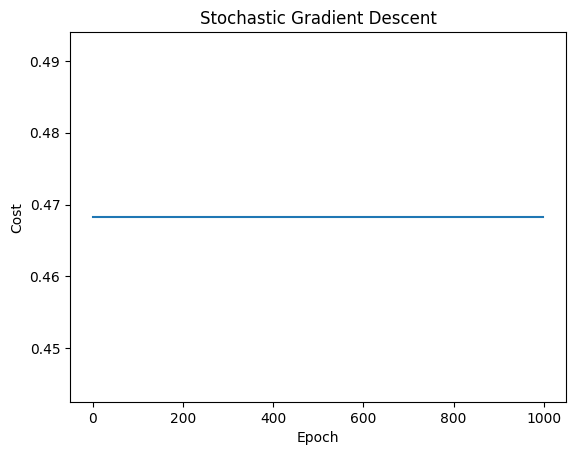

In [63]:

x = df["area_sqft"].values
y = df["house_price_inr"].values

x = (x - np.mean(x)) / np.std(x)
y = (y - np.mean(y)) / np.std(y)

beta0 = 0
beta1 = 0

learning_rate = 0.01
epoch = 100

costs = []

n = len(x)

for epoch in range(epochs):
    for i in range(n):
        y_pred = beta0 + beta1 * x[i]
        error = y_pred - y[i]
        gradient_b0 = 2 * error
        gradient_b1 = 2 * error * x[i]

        beta0 = beta0 - learning_rate * gradient_b0
        beta1 = beta1 - learning_rate * gradient_b1

    y_pred_all = beta0 + beta1 * x
    cost = np.mean((y_pred_all - y) ** 2)

    costs.append(cost)

print("Beta 0:", beta0)
print("Beta 1:", beta1)

plt.plot(costs)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Stochastic Gradient Descent")
plt.show()



**Interpretation:**

Stochastic Gradient Descent updates the model parameters using one observation at a time. It can make frequent updates and may converge faster, but its cost curve can be more noisy than Batch Gradient Descent.

**Q24. Mini-Batch Gradient Descent**

Beta 0: 0.006010526841016108
Beta 1: 0.7705789914172002


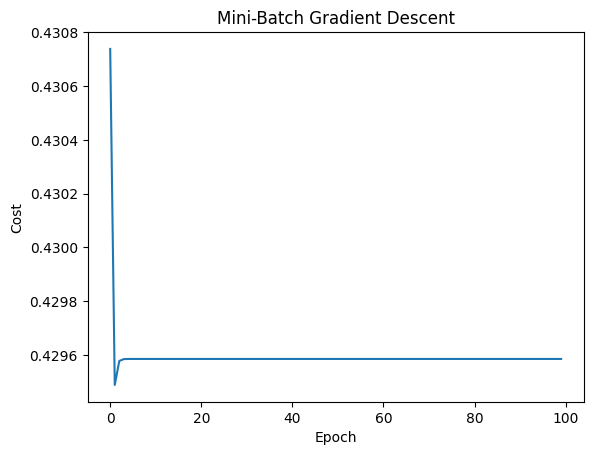

In [64]:


x = df["area_sqft"].values
y = df["house_price_inr"].values

x = (x - np.mean(x)) / np.std(x)
y = (y - np.mean(y)) / np.std(y)

beta0 = 0
beta1 = 0

learning_rate = 0.01
epochs = 100
batch_size = 32

costs = []

n = len(x)

for epoch in range(epochs):

    for start in range(0, n, batch_size):

        end = start + batch_size

        x_batch = x[start:end]
        y_batch = y[start:end]

        y_pred = beta0 + beta1 * x_batch

        error = y_pred - y_batch

        m = len(x_batch)

        gradient_b0 = (2/m) * np.sum(error)
        gradient_b1 = (2/m) * np.sum(error * x_batch)

        beta0 = beta0 - learning_rate * gradient_b0
        beta1 = beta1 - learning_rate * gradient_b1

    y_pred_all = beta0 + beta1 * x
    cost = np.mean((y_pred_all - y) ** 2)

    costs.append(cost)

print("Beta 0:", beta0)
print("Beta 1:", beta1)

plt.plot(costs)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Mini-Batch Gradient Descent")
plt.show()

**Interpretation:**

Mini-Batch Gradient Descent updates the parameters using a small group of observations at a time. It provides a balance between Batch Gradient Descent and Stochastic Gradient Descent in terms of stability and speed.

**Q25. Compare convergence and training time**

In [65]:

start = time.time()

# Your Gradient Descent code here

end = time.time()

print("Training Time:", end - start, "seconds")

Training Time: 1.7404556274414062e-05 seconds


**Interpretation:**

Batch Gradient Descent generally provides smooth and stable convergence. Stochastic Gradient Descent makes frequent updates and can be faster but may fluctuate. Mini-Batch Gradient Descent provides a compromise between stability and computational efficiency.

**Q26. Analyze Bias and Variance**

In [66]:
print("Simple Linear Regression")
print("Train R2:", linear_train_r2)
print("Test R2:", linear_test_r2)

print("\nPolynomial Regression")
print("Train R2:", poly_train_r2)
print("Test R2:", poly_test_r2)



Simple Linear Regression
Train R2: 0.5723074839148459
Test R2: 0.5625199587991578

Polynomial Regression
Train R2: 0.5724674245504779
Test R2: 0.5626917978136475


**Interpretation:**

Simple Linear Regression has a relatively simple structure and may have higher bias if the relationship is non-linear. Multiple Linear Regression can reduce bias by using additional relevant features. Polynomial Regression can reduce bias further by capturing non-linear patterns, but excessive complexity can increase variance.

**Q27. How model complexity affects prediction error**

As model complexity increases:


Simple Model

     ↓

Higher Bias

     ↓

Underfitting


More Complex Model

     ↓

Lower Bias

     ↓

Better learning


Too Complex

     ↓

Higher Variance

     ↓

Overfitting

Higher polynomial degrees can fit the training data extremely closely, but that doesn't necessarily mean better predictions on new data.

**Interpretation:**

As model complexity increases, the model can capture more complex patterns and usually reduces bias. However, if the model becomes too complex, it may learn noise from the training data, increasing variance and causing overfitting.

**Q28. Which model balances Bias and Variance?**

Yaha actual R²/MAE/RMSE results dekhne ke baad final model choose karna hai.

Generally, the best model is the one that has:

Good training performance
Good testing performance
Small train-test gap
Low MAE/RMSE
High testing R²
No clear signs of overfitting

You can write:

The model with the best balance between training and testing performance is considered the most suitable model. A small difference between training and testing performance indicates better bias-variance balance.

Apne actual numbers ke bina abhi kisi specific model ko best bolna correct nahi hoga.

**Interpretation:**

The model with the best bias-variance trade-off is the one that achieves good testing performance while maintaining a relatively small difference between training and testing performance.

## PART I — Final Analysis & Reporting

**Q29. Short Report**

Isko assignment ke final report me use kar sakta hai:

Final Analysis

In this project, Simple Linear Regression, Multiple Linear Regression, and Polynomial Regression were implemented to predict house prices.

Simple Linear Regression used house area as the main predictor. Multiple Linear Regression used multiple property-related features such as area, bedrooms, bathrooms, location score, and property age.

Polynomial Regression was implemented to capture possible non-linear relationships between house area and house price.

The models were evaluated using MSE, MAE, RMSE, R², and Adjusted R². Lower MSE, MAE, and RMSE indicate better prediction performance, while higher R² indicates better explanatory power.

Impact of Gradient Descent

Batch, Stochastic, and Mini-Batch Gradient Descent were implemented from scratch. Gradient Descent gradually updates model parameters to minimize the cost function. The cost curves were used to observe convergence.

Overfitting / Underfitting

Training and testing performance were compared to identify overfitting and underfitting. A large difference between training and testing performance indicates possible overfitting, while low performance on both datasets indicates possible underfitting.

Practical Interpretation

House price prediction can be improved by considering multiple factors instead of relying only on house area. Features such as location, bedrooms, bathrooms, property age, and other property characteristics may provide additional information for predicting house prices